Name:Bibek Shrestha
University Id:2418629

In [52]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/WEEK5/FruitinAmazon.zip"
extract_path = "dataset"        # folder where it will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [53]:
extract_path = "dataset/FruitinAmazon"
train_dir = os.path.join(extract_path, "train")

# Get class names (folder names)
classes = [folder for folder in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, folder))]

print("Classes:", classes)

Classes: ['graviola', 'guarana', 'acai', 'pupunha', 'cupuacu', 'tucuma']


In [54]:
import random

image_paths = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    random_image = random.choice(images)
    image_paths.append((cls, os.path.join(class_path, random_image)))

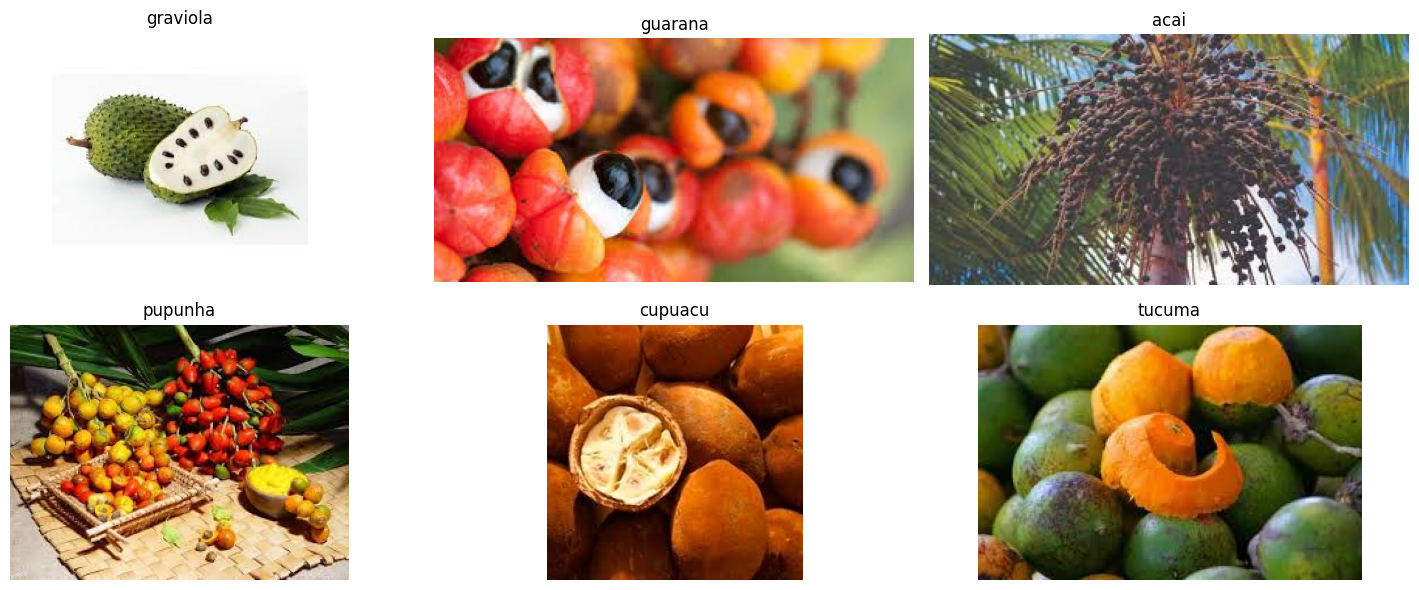

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import math

num_images = len(image_paths)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(15, 6))

for i, (cls, img_path) in enumerate(image_paths):
    plt.subplot(2, cols, i + 1)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
corrupted_images= []
for class_name in os.listdir(train_dir):
  class_path = os.path.join(train_dir,class_name)

  if not os.path.isdir(class_path):
        continue

  # Iterate through images in each class
  for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)

      try:
          # Try opening and verifying the image
          with Image.open(img_path) as img:
              img.verify()   # verifies image integrity

      except (IOError, SyntaxError):
          print(f"Removed corrupted image: {img_path}")
          corrupted_images.append(img_path)

          # Remove corrupted file
          os.remove(img_path)

# Final report
if len(corrupted_images) == 0:
  print("No Corrupted Images Found.")
else:
  print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in keras:

In [57]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Get class names BEFORE applying any map transformations to train_ds
class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Number of classes:", num_classes)
print("Class names:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Task 1.1: Data Augmentation

To increase the effective size of your training dataset and improve your model's generalization capabilities, we'll apply data augmentation techniques. This involves randomly transforming the training images (e.g., flipping, rotating, zooming) on the fly during training, so the model sees a slightly different version of each image in every epoch.

In [58]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import keras

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
]

@keras.saving.register_keras_serializable()
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

Task 3 - Implement a CNN


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras import layers

model = Sequential([

    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(224,224,3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])

Task 4: Compile the Model


In [60]:
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 6,814,278 (25.99 MB)

 Trainable params: 6,813,062 (25.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [62]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2830 - loss: 2.3368
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 7s/step - accuracy: 0.3333 - loss: 2.1925 - val_accuracy: 0.1667 - val_loss: 1.7336
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6510 - loss: 1.2036
Epoch 2: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.6250 - loss: 1.2478 - val_accuracy: 0.0000e+00 - val_loss: 2.4179
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6412 - loss: 1.0816
Epoch 3: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.6111 - loss: 1.1203 - val_accuracy: 0.0000e+00 - val_loss: 3.7955
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6267 - loss: 0.8950
Epoch 4: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5833 - loss: 1.0482 - val_accuracy: 0.0000e+00 - val_loss: 5.1047
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7118 - loss: 0.7856
Epoch 5: v

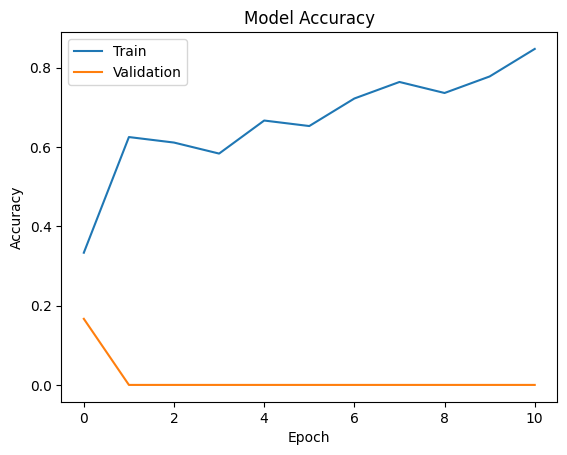

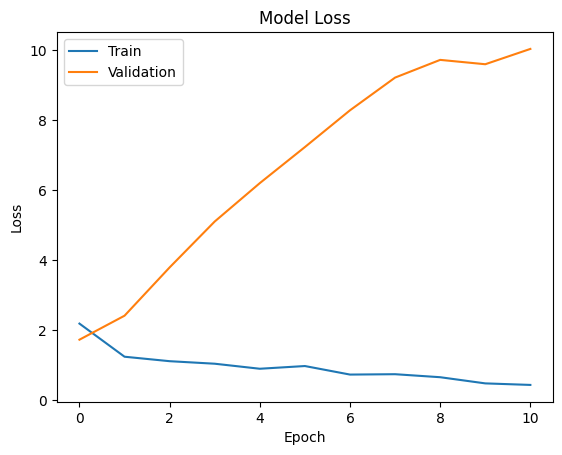

In [63]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [64]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.7336   
Test Accuracy: 0.1666666716337204
Test Loss: 1.733587622642517


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [65]:
model.save("final_model.h5")
print("Model saved!")

Model saved!


In [66]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.7336
Loaded Model Accuracy: 0.1666666716337204


Task 7: Predictions and Classification Report

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance

In [67]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in train_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, labels=np.arange(num_classes), target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
              precision    recall  f1-score   support

        acai       0.56      0.36      0.43        14
     cupuacu       0.36      0.62      0.46        13
    graviola       0.42      0.42      0.42        12
     guarana       0.25      0.10      0.14        10
     pupunha       0.42      0.91      0.57        11
      tucuma       1.00      0.08      0.15        12

    accuracy                           0.42        72
   macro avg       0.50      0.41      0.36        72
weighted avg       0.51      0.42      0.37        72



Transfer Learning (VGG16)

Load Pretrained VGG16 Model

In [68]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

Freeze pretrained layers

In [69]:
for layer in base_model.layers:
    layer.trainable = False

Build Transfer Learning Model

In [70]:
model_transfer = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

Compile the Model

In [71]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [72]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 17s/step - accuracy: 0.1250 - loss: 6.0956 - val_accuracy: 0.0000e+00 - val_loss: 9.6161
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 15s/step - accuracy: 0.5278 - loss: 3.1634 - val_accuracy: 0.1667 - val_loss: 3.7800
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 13s/step - accuracy: 0.7917 - loss: 0.7541 - val_accuracy: 0.6667 - val_loss: 1.1632
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 12s/step - accuracy: 0.9444 - loss: 0.1633 - val_accuracy: 0.9444 - val_loss: 0.1945
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 13s/step - accuracy: 0.9722 - loss: 0.1150 - val_accuracy: 0.9444 - val_loss: 0.1065
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 0.9028 - loss: 0.1367 - val_accuracy: 1.0000 - val_loss: 0.1061
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 14s/step - accuracy: 1.0000 - loss: 0.0189 - val_accuracy: 0.9444 - val_loss: 0.1413
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 14s/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.9444 - val_loss: 0.1

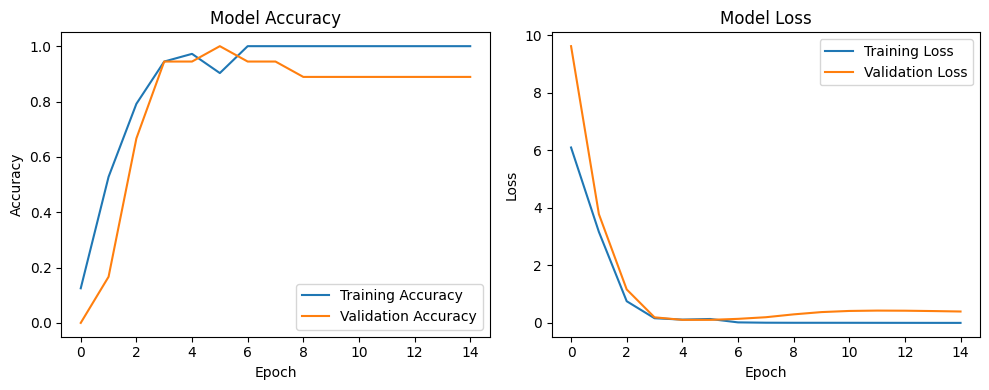

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluate the Model

In [79]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.8889 - loss: 0.3255
Transfer Learning Accuracy: 0.8888888955116272
Transfer Learning Loss: 0.3255068063735962


Fine-Tuning

In [75]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

Recompile with smaller learning rate

In [77]:
from tensorflow.keras.optimizers import RMSprop

model_transfer.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Fine-Tuned Model

In [76]:
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 1.0000 - loss: 9.7998e-04 - val_accuracy: 0.8889 - val_loss: 0.3815
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 1.0000 - loss: 7.6160e-04 - val_accuracy: 0.8889 - val_loss: 0.3691
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 1.0000 - loss: 6.2518e-04 - val_accuracy: 0.8889 - val_loss: 0.3598
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 1.0000 - loss: 5.6955e-04 - val_accuracy: 0.8889 - val_loss: 0.3522
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 5.0132e-04 - val_accuracy: 0.8889 - val_loss: 0.3436
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step - accuracy: 1.0000 - loss: 4.6075e-04 - val_accuracy: 0.8889 - val_loss: 0.3366
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 4.1460e-04 - val_accuracy: 0.8889 - val_loss: 0.3324
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 3.8250e-04 - val_accu

Final Evaluation

In [78]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.8889 - loss: 0.3255
Fine-Tuned Model Accuracy: 0.8888888955116272
